# Boundary transport verification

In this notebook we investigate transports through the open boundaries of our HYCOM domain. To this end, we compare transports of a HYCOM run and the GLORYS reanalysis, both through the open boundaries of the TOPAZ Arctic domain, on their respective native grids.

In [1]:
import numpy as np
import xarray as xr
import xhycom
import matplotlib.pyplot as plt

In [2]:
GRID_PATH  = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH  = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"

In [3]:
grid = xhycom.open_dataset(GRID_PATH)
bathy = xhycom.open_dataset(BATHY_PATH, grid=GRID_PATH)
ds = xhycom.open_mfdataset(
    DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1}, postprocess=True
)

In [4]:
glorys_data = xr.open_mfdataset(
    "/nird/datapeak/NS9481K/MERCATOR_DATA/PHY/2020/MERCATOR-PHY-24-2020-*.nc",
    chunks={"time": 1},
)
glorys_bathy = xr.open_dataset("/nird/datapeak/NS9481K/MERCATOR_DATA/REGULAR_GRID_COORD/GLO-MFC_001_030_mask_bathy.nc")

## Boundary transects

### Why the two models need different objects

HYCOM runs on a rotated curvilinear C-grid where velocities live at cell faces, while
GLORYS is on a regular lat/lon grid with velocities at cell centres.  Computing a
section transport therefore requires a different approach for each dataset.

For **HYCOM**, `tp2_sections` selects the exact V-faces at the boundary row and
integrates layer-by-layer thickness × velocity directly — no interpolation, no
rotation.  Sign convention (positive = into domain) is set at construction time.

For **GLORYS**, the section path is derived from the HYCOM boundary row positions,
extended slightly beyond the TP2 corners to ensure the path endpoints land on GLORYS land
(the two land masks differ slightly), and then resolved by snapping to the
nearest GLORYS T-cell centres.  The Aleutian Arc is a separate fixed transect that
closes a gap in the Pacific boundary where the HYCOM land mask has no ocean cells but
GLORYS does.


In [5]:
%%time

sec = xhycom.tp2_sections(grid, bathy, glorys_data)

print(f"HYCOM  Atlantic:  {sec.hycom_atlantic_boundary.n_cells} T-cells, {sec.hycom_atlantic_boundary.n_faces} V-faces, {sec.hycom_atlantic_boundary.distance_km[-1]:.0f} km")
print(f"HYCOM  Pacific:   {sec.hycom_pacific_boundary.n_cells} T-cells, {sec.hycom_pacific_boundary.n_faces} V-faces, {sec.hycom_pacific_boundary.distance_km[-1]:.0f} km")
print(f"GLORYS Atlantic:  {sec.glorys_atlantic_boundary.n_cells} T-cells, {sec.glorys_atlantic_boundary.distance_km[-1]:.0f} km")
print(f"GLORYS Pacific:   {sec.glorys_pacific_boundary.n_cells} T-cells, {sec.glorys_pacific_boundary.distance_km[-1]:.0f} km")
print(f"Aleutian Arc:     {sec.glorys_aleutian_boundary.n_cells} T-cells, {sec.glorys_aleutian_boundary.distance_km[-1]:.0f} km")

HYCOM  Atlantic:  177 T-cells, 177 V-faces, 3561 km
HYCOM  Pacific:   98 T-cells, 98 V-faces, 1293 km
GLORYS Atlantic:  718 T-cells, 4348 km
GLORYS Pacific:   303 T-cells, 1992 km
Aleutian Arc:     213 T-cells, 1339 km
CPU times: user 2.91 s, sys: 39.6 ms, total: 2.95 s
Wall time: 2.95 s


<div class="alert alert-info">

**TP5 domains:** replace `tp2_sections` with `tp5_sections` — the call signature,
the returned `DomainSections` type, and all transport calls are identical.  The GLORYS
section paths (southern, northern, and Aleutian Arc) are the same hardcoded paths
derived from the TP2 boundary rows; the GLORYS grid covers both domains so no
re-extraction is needed.

</div>

Here are the HYCOM sections on its native grid.

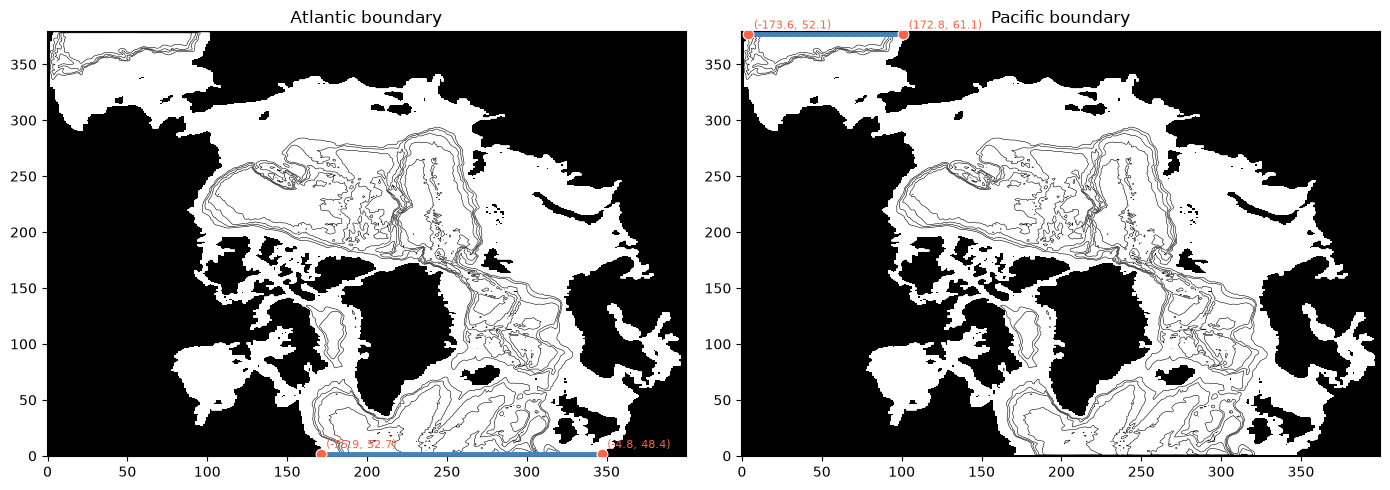

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, rt, title in [
    (axes[0], sec.hycom_atlantic_boundary, "Atlantic boundary"),
    (axes[1], sec.hycom_pacific_boundary,  "Pacific boundary"),
]:
    rt.plot(ax=ax, grid=grid, bathy=bathy)
    ax.set_title(title)
plt.tight_layout()

And here are all sections plotted together.

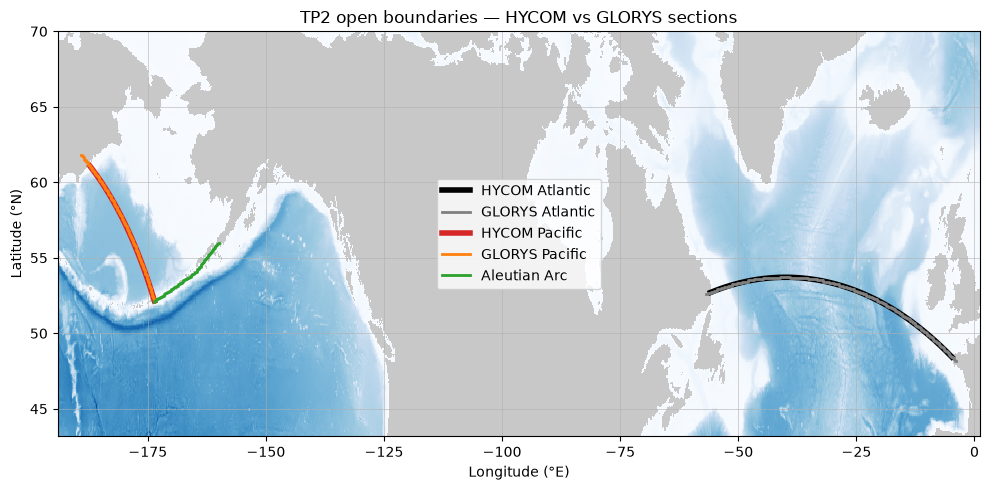

In [7]:
cmap = plt.cm.Blues.copy()
cmap.set_bad("#c8c8c8")  # land = gray

from xhycom._boundaries import _unwrap_lons

all_lons = np.concatenate([
    _unwrap_lons(sec.hycom_atlantic_boundary.cell_lon), _unwrap_lons(sec.glorys_atlantic_boundary.cell_lon),
    _unwrap_lons(sec.hycom_pacific_boundary.cell_lon),  _unwrap_lons(sec.glorys_pacific_boundary.cell_lon),
    np.array(sec.glorys_aleutian_boundary.cell_lon),
])
all_lats = np.concatenate([
    sec.hycom_atlantic_boundary.cell_lat, sec.glorys_atlantic_boundary.cell_lat,
    sec.hycom_pacific_boundary.cell_lat,  sec.glorys_pacific_boundary.cell_lat,
    sec.glorys_aleutian_boundary.cell_lat,
])
pad = 5.0
lon0, lon1 = all_lons.min() - pad, all_lons.max() + pad
lat0 = all_lats.min() - pad

depth = glorys_bathy["deptho"].sel(latitude=slice(lat0, 80.0))
lons_g = depth.longitude.values
lat_g  = depth.latitude.values
dep_v  = depth.values

fig, ax = plt.subplots(figsize=(10, 5))
# Tile the bathymetry at ±360° offsets so sections that cross the date line
# are covered regardless of which longitude convention the unwrapped path uses.
for offset in [-360, 0, 360]:
    shifted = lons_g + offset
    if shifted.max() < lon0 or shifted.min() > lon1:
        continue
    ax.pcolormesh(shifted, lat_g, dep_v, cmap=cmap, shading="nearest")

ax.plot(_unwrap_lons(sec.hycom_atlantic_boundary.cell_lon),  sec.hycom_atlantic_boundary.cell_lat,  color="black",      lw=4, label="HYCOM Atlantic")
ax.plot(_unwrap_lons(sec.glorys_atlantic_boundary.cell_lon), sec.glorys_atlantic_boundary.cell_lat, color="gray",       lw=2, label="GLORYS Atlantic")
ax.plot(_unwrap_lons(sec.hycom_pacific_boundary.cell_lon),   sec.hycom_pacific_boundary.cell_lat,   color="tab:red",    lw=4, label="HYCOM Pacific")
ax.plot(_unwrap_lons(sec.glorys_pacific_boundary.cell_lon),  sec.glorys_pacific_boundary.cell_lat,  color="tab:orange", lw=2, label="GLORYS Pacific")
ax.plot(sec.glorys_aleutian_boundary.cell_lon, sec.glorys_aleutian_boundary.cell_lat,               color="tab:green",  lw=2, label="Aleutian Arc")
ax.set_xlim(lon0, lon1)
ax.set_ylim(lat0, 70.0)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("TP2 open boundaries — HYCOM vs GLORYS sections")
ax.legend(loc="center")
ax.grid(True, lw=0.4)
plt.tight_layout()

## Compute transports for the year 2020

HYCOM transports are computed via `transport()` on the V-face `ResolvedTransect`, which performs a face-exact C-grid integration. GLORYS transports use the same call with `z_dim="depth"` on the T-cell `Transect`, which projects velocities onto the section normal at T-point locations.

In [8]:
%%time

tr_atlantic = xhycom.transport(ds, sec.hycom_atlantic_boundary).load()
tr_pacific  = xhycom.transport(ds, sec.hycom_pacific_boundary).load()

CPU times: user 2min 44s, sys: 38.9 s, total: 3min 23s
Wall time: 1min 58s


In [9]:
# HYCOM time is cftime; convert to datetime64 for shared matplotlib axes
tr_atlantic = tr_atlantic.assign_coords(time=tr_atlantic.indexes["time"].to_datetimeindex(time_unit="ns"))
tr_pacific  = tr_pacific.assign_coords(time=tr_pacific.indexes["time"].to_datetimeindex(time_unit="ns"))

In [10]:
%%time

tpoint_kw  = dict(u_var="uo", v_var="vo", t_var="thetao", s_var="so", z_dim="depth")

tr_atlantic_g = xhycom.transport(glorys_data, sec.glorys_atlantic_boundary, **tpoint_kw).compute()
tr_pacific_g  = xhycom.transport(glorys_data, sec.glorys_pacific_boundary,  **tpoint_kw).compute()
tr_aleutian_g = xhycom.transport(glorys_data, sec.glorys_aleutian_boundary, **tpoint_kw).compute()

CPU times: user 26min 28s, sys: 25min 39s, total: 52min 7s
Wall time: 28min 9s


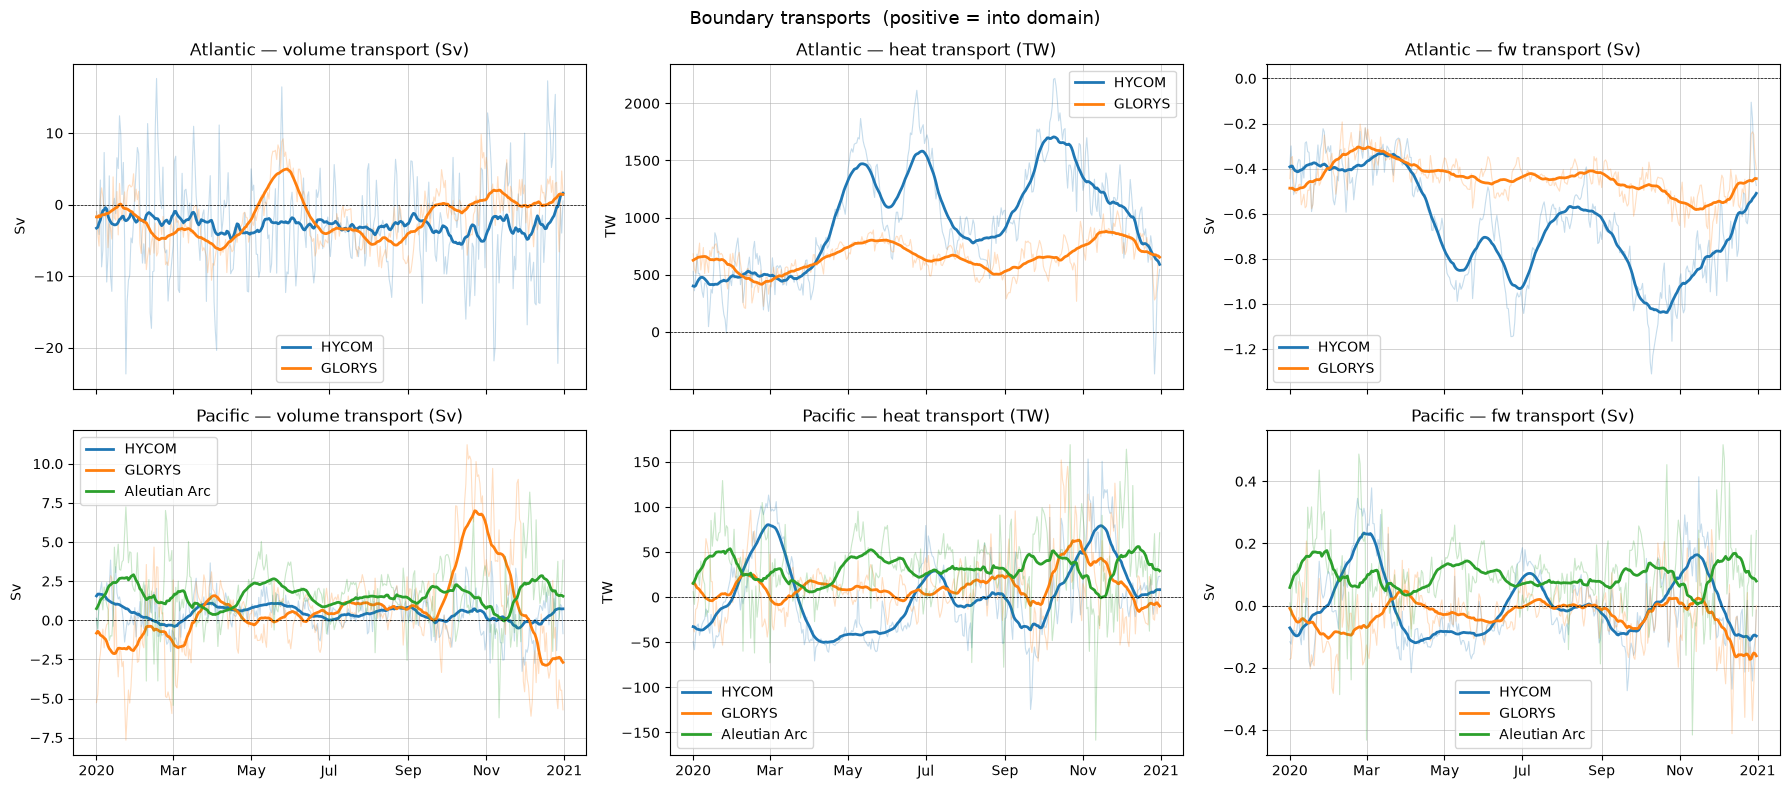

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

for row, (tr_h, tr_g, tr_b, label) in enumerate([
    (tr_atlantic, tr_atlantic_g, None,          "Atlantic"),
    (tr_pacific,  tr_pacific_g,  tr_aleutian_g, "Pacific"),
]):
    for col, (var, units) in enumerate([("volume", "Sv"), ("heat", "TW"), ("fw", "Sv")]):
        ax = axs[row, col]

        c_h, c_g, c_b = "tab:blue", "tab:orange", "tab:green"
        kw_raw  = dict(lw=0.8, alpha=0.25)
        kw_roll = dict(lw=2.0)

        tr_h[var].plot(ax=ax, color=c_h, **kw_raw, label="_nolegend_")
        tr_g[var].plot(ax=ax, color=c_g, **kw_raw, label="_nolegend_")
        tr_h[var].rolling(time=30, center=True, min_periods=1).mean().plot(ax=ax, color=c_h, **kw_roll, label="HYCOM")
        tr_g[var].rolling(time=30, center=True, min_periods=1).mean().plot(ax=ax, color=c_g, **kw_roll, label="GLORYS")

        if tr_b is not None:
            tr_b[var].plot(ax=ax, color=c_b, **kw_raw, label="_nolegend_")
            tr_b[var].rolling(time=30, center=True, min_periods=1).mean().plot(ax=ax, color=c_b, **kw_roll, label="Aleutian Arc")

        ax.axhline(0, color="k", lw=0.5, ls="--")
        ax.set_title(f"{label} — {var} transport ({units})")
        ax.set_ylabel(units)
        ax.set_xlabel("")
        ax.legend()
        ax.grid(True, lw=0.4)

fig.suptitle("Boundary transports  (positive = into domain)", fontsize=13)
plt.tight_layout()

## Interpretation

The figure is a sanity check that HYCOM is receiving GLORYS at its boundaries
correctly: similar magnitude, sign, and seasonal phase between the two models means
the section geometry and transport integration are working as intended. Note that the
Aleutian Arc has no HYCOM counterpart, so the most informative comparison for the
Pacific boundary is between the HYCOM (blue) and GLORYS Pacific (orange) lines.

### How HYCOM applies the GLORYS boundary conditions

This experiment uses **full 3-D nesting** (`nestfq = bnstfq = 1`, `lbflag = 2`,
`relax = 0`).  A daily GLORYS archive is read every model day and nudged into a sponge
zone adjacent to each open boundary.  Unlike pure T/S relaxation, the 3-D nesting
scheme in `thermf.F` applies Newtonian relaxation to **all prognostic fields**:
temperature, salinity, layer pressure (thickness), and both horizontal velocity
components (u, v).  The nudging strength is spatially varying and read from
`nest/rmu.a` (a separate mask file for tracers, `rmunp`, and for velocity, `rmunv`).

For the barotropic mode (`lbflag = 2`) HYCOM applies the **Browning-Kreiss** open
boundary condition (`latbdt` in `latbdy.F`), a radiation-type scheme that lets
outgoing barotropic waves leave the domain freely while constraining the incoming
signal to the nesting data.  This is imposed every barotropic sub-step.

### Why the transports do not match 1:1

Even with daily velocity nudging, the comparison is imperfect. The Browning-Kreiss
condition modifies the barotropic velocity at the boundary to allow wave radiation, so
it is not a simple copy of the GLORYS depth-mean flow. The residual differences reflect
how much the interior HYCOM dynamics reshape the boundary-region (out)flow beyond what
the nudging prescribes.